## Our Results

In [1]:
import os
import re
import ast
import pandas as pd

models = ['sasrec', 'caser', 'gru']
combs = [[1,1,1],[1,1,0],[1,0,1],[0,1,1],[0,1,0],[0,0,1]]
model_stop = ["main", "target"]
datasets = ["rc15_results"]
# MODIFY PATH TO div4rec dir of Paparellas
div4rec_path = "/home/marek/Kinit/my_smorl/data"
results_dir = "/home/marek/Kinit/my_smorl/Plots/Havrila_both"
os.makedirs(results_dir, exist_ok=True)


In [16]:
patterns = {
    # Matches: cumulative reward @ 5: 8585.000000
    'cumulative_reward': re.compile(r'.*cumulative reward @ (\d+): ([\d.]+)$'),

    # Matches: clicks hr ndcg @ 10 : 0.398485, 0.241570
    'clicks_hr_ndcg': re.compile(r'.*clicks hr ndcg @ (\d+) ?: ([\d.]+), ([\d.]+)$'),

    # Matches: purchase hr and ndcg @10 : 0.535500, 0.337177
    'purchase_hr_ndcg': re.compile(r'.*purchase hr and ndcg @(\d+) ?: ([\d.]+), ([\d.]+)$'),

    # Matches: total diversity reward: 48740.039062
    'total_diversity': re.compile(r'.*total diversity reward: ([\d.]+)$'),

    # Matches: total novelty reward: 19004.000000
    'total_novelty': re.compile(r'.*total novelty reward: ([\d.]+)$'),

    # Matches: coverage of top 5 predictions: 0.379410
    'coverage': re.compile(r'.*coverage of top (\d+) predictions: ([\d.]+)$'),

    # Matches: coverage on novel items of top 10 predictions: 0.385095
    'novel_coverage': re.compile(r'.*coverage on novel items of top (\d+) predictions: ([\d.]+)$'),

    # Matches: average number of repetitions in top 20: 53.379500
    'avg_repetitions': re.compile(r'.*average number of repetitions in top (\d+): \s*({.*})'),
    
    'steps': re.compile(r'.*Step: (\d+)\.+\s+Loss: ([\d.]+)$'),
    'Slosses': re.compile(r'.*Supervised loss is ([\d.]+), SMORL loss is ([\d.]+)'),
    'Mlosses': re.compile(r'.*Supervised loss is ([\d.]+), MORL loss is ([\d.]+)')
}

#### Data preparation - parsing text output files

In [17]:
def process_results(data_path, results_path, variant, dats):
    eval_step = {'rc15_results': 5000, 'retail_rocket_results': 10000}
    
    loss = {
        'steps': [], 'loss': [], 'plain': [], 'smorl': []
    }
    metrics = {
        'steps': [],
        'hr_test_5': [], 'hr_test_10': [], 'hr_test_20': [],
        'ndcg_test_5': [], 'ndcg_test_10': [], 'ndcg_test_20': [],
        'cov_test_1': [], 'cov_test_5': [], 'cov_test_10': [], 'cov_test_20': [],
        'nov_test_1': [], 'nov_test_5': [], 'nov_test_10': [], 'nov_test_20': [],
        'rep_test_5': [], 'rep_test_10': [], 'rep_test_20': [],        
        'hr_val_5': [], 'hr_val_10': [], 'hr_val_20': [], 
        'ndcg_val_5': [], 'ndcg_val_10': [], 'ndcg_val_20': [],
        'cov_val_1': [], 'cov_val_5': [], 'cov_val_10': [], 'cov_val_20': [],        
        'nov_val_1': [], 'nov_val_5': [], 'nov_val_10': [], 'nov_val_20': [],
        'rep_val_5': [], 'rep_val_10': [], 'rep_val_20': [] 
    }
    with open(data_path, "r") as f:
        lines = f.readlines()
        my_model = "any"  
        for line in lines:
            #match = re.search(r"Step: (\d+)\.+\s+Loss: ([\d.]+)", line)
            if m := patterns['Slosses'].search(line):
                plain, smorl = float(m.group(1)), float(m.group(2))
                loss['plain'].append(plain)
                loss['smorl'].append(smorl)
            if m := patterns['Mlosses'].search(line):
                plain, smorl = float(m.group(1)), float(m.group(2))
                loss['plain'].append(plain)
                loss['smorl'].append(smorl)
            if m := patterns['steps'].match(line):
                step, _loss = int(m.group(1)), float(m.group(2))
                loss['steps'].append(step)
                loss['loss'].append(_loss)
            if "Model is" in line:
                my_model = "any"
            if "Evaluating Target Model" in line:
                my_model = "target"
            if "Evaluating Main Model" in line:
                my_model = "main"
            if my_model == variant:
                continue   
            if "TEST" in line:
                if m := patterns['clicks_hr_ndcg'].match(line):
                    k, hr, ndcg = int(m.group(1)), float(m.group(2)), float(m.group(3))
                    metrics[f'hr_test_{k}'].append(hr)
                    metrics[f'ndcg_test_{k}'].append(ndcg)
                elif m := patterns['coverage'].match(line):
                    k, val = int(m.group(1)), float(m.group(2))
                    metrics[f'cov_test_{k}'].append(val)
                elif m := patterns['novel_coverage'].match(line):
                    k, val = int(m.group(1)), float(m.group(2))
                    metrics[f'nov_test_{k}'].append(val)
                elif m := patterns['avg_repetitions'].match(line):
                    k, val = int(m.group(1)), m.group(2)
                    repetitions = ast.literal_eval(val)
                    value = repetitions.get(5)
                    metrics[f'rep_test_{k}'].append(value)
            else:
                if m := patterns['clicks_hr_ndcg'].match(line):
                    k, hr, ndcg = int(m.group(1)), float(m.group(2)), float(m.group(3))
                    metrics[f'hr_val_{k}'].append(hr)
                    metrics[f'ndcg_val_{k}'].append(ndcg)
                elif m := patterns['coverage'].match(line):
                    k, val = int(m.group(1)), float(m.group(2))
                    metrics[f'cov_val_{k}'].append(val)
                elif m := patterns['novel_coverage'].match(line):
                    k, val = int(m.group(1)), float(m.group(2))
                    metrics[f'nov_val_{k}'].append(val)
                elif m := patterns['avg_repetitions'].match(line):
                    k, val = int(m.group(1)), m.group(2)
                    repetitions = ast.literal_eval(val)
                    value = repetitions.get(5)
                    metrics[f'rep_val_{k}'].append(value)
        metrics['steps'] = [eval_step[dats] * (i + 1) for i in range(len(metrics['hr_test_5']))]
    
    return loss, metrics

for model in models:
    for comb in combs:
        for variant in model_stop:
            for dats in datasets:
                if "rc15" in dats:
                    file_path = f'{div4rec_path}/{model}_RL/{model}_smorl1_acc{comb[0]}.0_div{comb[1]}.0_nov{comb[2]}.0_weighted_q_vals.txt'
                else:
                    file_path = f'{div4rec_path}/{dats}/{model}smorl/{model}_smorl1_acc{comb[0]}.0_div{comb[1]}.0_nov{comb[2]}.0_weighted_q_vals.txt'
                results_path = f'{results_dir}/{dats}/{model}'
                os.makedirs(results_path, exist_ok=True)
                results = f"{results_path}/rl_{comb[0]}{comb[1]}{comb[2]}_{variant}"
                losses, metrics = process_results(file_path, results, variant, dats)
                df_loss = pd.DataFrame(losses)
                df_metrics = pd.DataFrame(metrics)
                df_loss.to_pickle(f'{results}_loss')
                df_loss.to_csv(f'{results}_loss.csv')
                df_metrics.to_pickle(f'{results}_metrics')
                df_metrics.to_csv(f'{results}_metrics.csv')
                
models.append('nextitnet')
for model in models:
    for dats in datasets:
        file_path = f'/home/marek/Kinit/my_smorl/data/{model}_vanilla_sk1/{model}.txt'
        results = f"{results_dir}/{dats}/{model}"
        os.makedirs(results, exist_ok=True)
        losses, metrics = process_results(file_path, results, "This is not rl - not distinguished", dats)
        losses = {k: v for k, v in losses.items() if k not in {'plain', 'smorl'}}
        df_loss = pd.DataFrame(losses)
        df_metrics = pd.DataFrame(metrics)
        df_loss.to_pickle(f'{results}/base_loss')
        df_loss.to_csv(f'{results}/base_loss.csv')
        df_metrics.to_pickle(f'{results}/base_metrics')
        df_metrics.to_csv(f'{results}/base_metrics.csv')


model = "nextitnet"
for variant in model_stop:
    for dats in datasets:
        if "rc15" in dats:
            file_path = f'{div4rec_path}/{model}_RL/{model}_smorl1_acc1.0_div1.0_nov1.0.txt'
        else:
            file_path = f'{div4rec_path}/{dats}/{model}smorl/{model}_smorl1_acc1.0_div1.0_nov1.0.txt'
        results = f"{results_dir}/{dats}/{model}/rl_111_{variant}"
        losses, metrics = process_results(file_path, results, variant, dats)
        df_loss = pd.DataFrame(losses)
        df_metrics = pd.DataFrame(metrics)
        df_loss.to_pickle(f'{results}_loss')
        df_loss.to_csv(f'{results}_loss.csv')  
        df_metrics.to_pickle(f'{results}_metrics')
        df_metrics.to_csv(f'{results}_metrics.csv')

#### Plots portrait format - RC15

In [26]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import scienceplots

plt.style.use(['science', 'no-latex'])

grey = cm.get_cmap('Greys')
green = cm.get_cmap('Greens')

def plot_helper(ax, df0, dfs, df6, PLOT, col1, col2, window=1):
    yname = ylab_helper(PLOT)
    ax.set_ylabel(yname, color=col1)
    ax.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color=col1, linestyle=":", linewidth=2)
    #for frame in dfs:
    #    ax.plot(frame['steps'], frame[PLOT].rolling(window).mean(), color=col2, linewidth=1)
    if len(dfs) > 0:
        ax.plot(dfs[0]['steps'], dfs[0][PLOT].rolling(window).mean(), color=col2(0.2), linewidth=1)
        ax.plot(dfs[1]['steps'], dfs[1][PLOT].rolling(window).mean(), color=col2(0.3), linewidth=1)
        ax.plot(dfs[2]['steps'], dfs[2][PLOT].rolling(window).mean(), color=col2(0.4), linewidth=1)
        ax.plot(dfs[3]['steps'], dfs[3][PLOT].rolling(window).mean(), color=col2(0.5), linewidth=1)
        ax.plot(dfs[4]['steps'], dfs[4][PLOT].rolling(window).mean(), color=col2(0.6), linewidth=1)
    ax.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color=col1, linewidth=1)      
       
def ylab_helper(name):
    if name.startswith("hr_") and name.endswith("_10"):
        label = 'HR@10'
    elif name.startswith("ndcg_") and name.endswith("_10"):
        label = 'nDCG@10'
    elif name.startswith("cov_") and name.endswith("_10"):
        label = 'COV@10'
    elif name.startswith("nov_") and name.endswith("_10"):
        label = 'NOV@10'
    elif name.startswith("rep_") and name.endswith("_5"):
        label = 'REP@5'
    elif name == "smorl":
        label = 'RL-head loss'
    elif name == "plain":
        label = 'self-supervised loss'
    else:
        label = name
    return label

def plot_metrics(basepath, dataset, model, replica, testorval, window=1):
    filepath = f"{basepath}/{dataset}/{model}"
    dataline = "metrics"
    df0 = pd.read_pickle(f"{filepath}/base_{dataline}")
    try:
        df1 = pd.read_pickle(f"{filepath}/rl_001_{replica}_{dataline}")
        df2 = pd.read_pickle(f"{filepath}/rl_010_{replica}_{dataline}")
        df3 = pd.read_pickle(f"{filepath}/rl_011_{replica}_{dataline}")
        df4 = pd.read_pickle(f"{filepath}/rl_110_{replica}_{dataline}")
        df5 = pd.read_pickle(f"{filepath}/rl_101_{replica}_{dataline}")
        dfs = [df1, df2, df3, df4, df5]
    except:
        dfs = []
    df6 = pd.read_pickle(f"{filepath}/rl_111_{replica}_{dataline}")
    
    #~~~~~~ Plot cov + nov values ~~~~~~
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    fig.suptitle(f'Havrila : {dataset}-{model}-{replica}-{testorval}', fontsize=12, y=0.94)
     
    PLOT = f"cov_{testorval}_10"
    ax1 = axs[0, 0]
    #ax1.set_title("COV 10 / NOV 10", fontsize=10, pad=10)
    ax1.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax1.set_ylabel(yname, color="black")
    ax1.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2, label="vanilla")
    if len(dfs) > 0:
        ax1.plot(dfs[0]['steps'], dfs[0][PLOT].rolling(window).mean(), color='0.2', linewidth=1)
        ax1.plot(dfs[1]['steps'], dfs[1][PLOT].rolling(window).mean(), color='0.3', linewidth=1)
        ax1.plot(dfs[2]['steps'], dfs[2][PLOT].rolling(window).mean(), color='0.4', linewidth=1)
        ax1.plot(dfs[3]['steps'], dfs[3][PLOT].rolling(window).mean(), color='0.5', linewidth=1)
        ax1.plot(dfs[4]['steps'], dfs[4][PLOT].rolling(window).mean(), color='0.6', linewidth=1)
    ax1.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color="black", linewidth=1, label="RL")
    
    PLOT = f"nov_{testorval}_10"
    ax2 = ax1.twinx()
    ax2.set_ylim(0.1, 0.75)
    plot_helper(ax2, df0, dfs, df6, PLOT, 'green', green)
       
    #~~~~~~ Plot cov + nov aligned ~~~~~~
    PLOT = f"cov_{testorval}_10"
    ax3 = axs[0, 1]
    #ax3.set_title("COV 10 / NOV 10 Alignment", fontsize=10, pad=10)
    yname = ylab_helper(PLOT)
    ax3.set_ylabel(yname, color='black')
    ax3.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2)
    if len(dfs) > 0:
        ax3.plot(dfs[0]['steps'], dfs[0][PLOT].rolling(window).mean(), color='0.2', linewidth=1)
        ax3.plot(dfs[1]['steps'], dfs[1][PLOT].rolling(window).mean(), color='0.3', linewidth=1)
        ax3.plot(dfs[2]['steps'], dfs[2][PLOT].rolling(window).mean(), color='0.4', linewidth=1)
        ax3.plot(dfs[3]['steps'], dfs[3][PLOT].rolling(window).mean(), color='0.5', linewidth=1)
        ax3.plot(dfs[4]['steps'], dfs[4][PLOT].rolling(window).mean(), color='0.6', linewidth=1)
    ax3.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color='lightgray', linewidth=4)
    
    PLOT = f"nov_{testorval}_10"
    ax4 = ax3.twinx()
    plot_helper(ax4, df0, dfs, df6, PLOT, 'green', green)
    
    #~~~~~~ Plot hr + ndcg ~~~~~~   
    PLOT = f"hr_{testorval}_10"
    ax5 = axs[1, 0]
    #ax5.set_title("HR 10 / NDCG 10", fontsize=10, pad=10)
    plot_helper(ax5, df0, dfs, df6, PLOT, 'black', grey)
        
    PLOT = f"ndcg_{testorval}_10"
    ax6 = ax5.twinx()
    plot_helper(ax6, df0, dfs, df6, PLOT, 'green', green) 
        
    # ~~~~~~ Plot repetitivness ~~~~~~
    PLOT = f"rep_{testorval}_5"
    ax7 = axs[1, 1]
    #ax7.set_title("REP 5", fontsize=10, pad=10)
    ax7.yaxis.set_label_position("right")
    ax7.yaxis.tick_right()  
    plot_helper(ax7, df0, dfs, df6, PLOT, 'black', grey)
    
    # ~~~~~~ Plot losses ~~~~~~
    dataline = "loss"
    dfl0 = pd.read_pickle(f"{filepath}/base_{dataline}")
    try:
        dfl1 = pd.read_pickle(f"{filepath}/rl_001_{replica}_{dataline}")
        dfl2 = pd.read_pickle(f"{filepath}/rl_010_{replica}_{dataline}")
        dfl3 = pd.read_pickle(f"{filepath}/rl_011_{replica}_{dataline}")
        dfl4 = pd.read_pickle(f"{filepath}/rl_110_{replica}_{dataline}")
        dfl5 = pd.read_pickle(f"{filepath}/rl_101_{replica}_{dataline}")
        dfls = [dfl1, dfl2, dfl3, dfl4, dfl5]
    except:
        dfls = []
    dfl6 = pd.read_pickle(f"{filepath}/rl_111_{replica}_{dataline}") 
    
    PLOT = "loss"
    ax8 = axs[2, 0]
    #ax8.set_title("Loss", fontsize=10, pad=10)
    ax8.yaxis.set_label_position("left")
    ax8.set_ylim(0, 10)
    ax8.yaxis.tick_left()
    ax8.set_xlabel("Steps", color='black')
    plot_helper(ax8, dfl0, dfls, dfl6, PLOT, 'black', grey, 5)
          
    PLOT = "plain"
    ax9 = axs[2, 1]
    #ax9.set_title("Loss components", fontsize=10, pad=10)
    yname = ylab_helper(PLOT)
    ax9.set_ylabel(yname, color='black')
    ax9.set_ylim(0, 10)
    ax9.set_xlabel("Steps", color='black')
    for frame in dfls:
        ax9.plot(frame['steps'], frame[PLOT].rolling(5).mean(), color='lightgray', linewidth=1)
    ax9.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='black', linewidth=1)

    PLOT = "smorl"
    ax10 = ax9.twinx()
    ax10.set_ylabel(PLOT, color='green')
    yname = ylab_helper(PLOT)
    ax10.set_ylabel(yname, color='green')
    ax10.set_ylim(0, 10)
    for frame in dfls:
        ax10.plot(frame['steps'], frame[PLOT].rolling(5).mean(), color='lightgreen', linewidth=1)
    ax10.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='green', linewidth=1)
    
    for i, ax in enumerate(axs.flat):
        ax.yaxis.grid(True, color='lightgray', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        for child in ax.figure.axes:
            child.tick_params(axis='y', labelsize=8)
            child.tick_params(axis='x', labelsize=8)
    
    fig.legend(
        loc='lower center',
        ncol=2,                  # number of columns in legend
        bbox_to_anchor=(0.5, -0.02),  # center below figure
        fontsize='medium'
    )
    
    plt.subplots_adjust(wspace=0.3, hspace=0.2)
    
    fig.savefig(f"{basepath}{dataset}-{model}-{replica}-{testorval}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

models = ["gru", "caser", "sasrec", "nextitnet"]
#models = ["caser_rl_0.75", "gru_rl_0.75", "sasrec_rl_3", "nextitnet_rl_3"]
#models = ['fixed_sasrec_rl_1_100']
#models = ['zeroed_sasrec_rl_1']
#models = ['sasrec_rl_1_100']
#models = ['fixed_sasrec_rl_3_100']
#models = ['fixed_sasrec_rl_10_100']
basepath = "/home/marek/Kinit/my_smorl/Plots/Havrila_both/"
datasets = ['rc15_results']
for dataset in datasets:
    for model in models: 
        for replica in ['main', 'target']:
            for variant in ['test', 'val']:
                plot_metrics(basepath, dataset, model, replica, variant)
            

/tmp/ipykernel_2791187/4007543443.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  grey = cm.get_cmap('Greys')
/tmp/ipykernel_2791187/4007543443.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  green = cm.get_cmap('Greens')


#### Plots Retail Rocket

In [11]:
import pandas as pd
from matplotlib import pyplot as plt

def plot_helper(ax, df0, df1, df6, PLOT, col1, col2, window=1):
    yname = ylab_helper(PLOT)
    ax.set_ylabel(yname, color=col1)
    ax.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color=col1, linestyle=":", linewidth=2)
    ax.plot(df1['steps'], df1[PLOT].rolling(window).mean(), color=col2(0.5), linewidth=1)
    ax.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color=col1, linewidth=1)
    

def plot_metrics(basepath, dataset, model, replica, testorval, window=1):
    filepath1 = f"{basepath}Havrila_both/{dataset}/{model}"
    filepath2 = f"{basepath}Havrila_unfix/{dataset}/{model}"
    dataline = "metrics"
    df0 = pd.read_pickle(f"{filepath1}/base_{dataline}")
    df1 = pd.read_pickle(f"{filepath2}/rl_1_100_{replica}_{dataline}")
    df6 = pd.read_pickle(f"{filepath2}/rl_1_111_{replica}_{dataline}")
    
    #~~~~~~ Plot cov + nov values ~~~~~~
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    fig.suptitle(f'Havrila : {dataset}-{model}-{replica}-{testorval}', fontsize=12, y=0.94)
     
    PLOT = f"cov_{testorval}_10"
    ax1 = axs[0, 0]
    #ax1.set_title("COV 10 / NOV 10", fontsize=10, pad=10)
    ax1.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax1.set_ylabel(yname, color="black")
    ax1.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2, label="vanilla")
    ax1.plot(df1['steps'], df1[PLOT].rolling(window).mean(), color='0.5', linewidth=1, label="SQN")
    ax1.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color="black", linewidth=1, label="RL")
    
    PLOT = f"nov_{testorval}_10"
    ax2 = ax1.twinx()
    ax2.set_ylim(0.1, 0.75)
    plot_helper(ax2, df0, df1, df6, PLOT, 'green', green)
       
    #~~~~~~ Plot cov + nov aligned ~~~~~~
    PLOT = f"cov_{testorval}_10"
    ax3 = axs[0, 1]
    #ax3.set_title("COV 10 / NOV 10 Alignment", fontsize=10, pad=10)
    yname = ylab_helper(PLOT)
    ax3.set_ylabel(yname, color='black')
    ax3.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2)
    ax3.plot(df1['steps'], df1[PLOT].rolling(window).mean(), color='0.5', linewidth=1)
    ax3.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color='lightgray', linewidth=4)

    PLOT = f"nov_{testorval}_10"
    ax4 = ax3.twinx()
    plot_helper(ax4, df0, df1, df6, PLOT, 'green', green)
    
    #~~~~~~ Plot hr + ndcg ~~~~~~   
    PLOT = f"hr_{testorval}_10"
    ax5 = axs[1, 0]
    #ax5.set_title("HR 10 / NDCG 10", fontsize=10, pad=10)
    plot_helper(ax5, df0, df1, df6, PLOT, 'black', grey)
        
    PLOT = f"ndcg_{testorval}_10"
    ax6 = ax5.twinx()
    plot_helper(ax6, df0, df1, df6, PLOT, 'green', green) 
        
    # ~~~~~~ Plot repetitivness ~~~~~~
    PLOT = f"rep_{testorval}_5"
    ax7 = axs[1, 1]
    #ax7.set_title("REP 5", fontsize=10, pad=10)
    ax7.yaxis.set_label_position("right")
    ax7.yaxis.tick_right()  
    plot_helper(ax7, df0, df1, df6, PLOT, 'black', grey)
    
    # ~~~~~~ Plot losses ~~~~~~
    dataline = "loss"
    dfl0 = pd.read_pickle(f"{filepath1}/base_{dataline}")
    dfl1 = pd.read_pickle(f"{filepath2}/rl_1_100_{replica}_{dataline}")
    dfl6 = pd.read_pickle(f"{filepath2}/rl_1_111_{replica}_{dataline}") 
    
    PLOT = "loss"
    ax8 = axs[2, 0]
    #ax8.set_title("Loss", fontsize=10, pad=10)
    ax8.yaxis.set_label_position("left")
    ax8.set_ylim(0, 10)
    ax8.yaxis.tick_left()
    ax8.set_xlabel("Steps", color='black')
    plot_helper(ax8, dfl0, dfl1, dfl6, PLOT, 'black', grey, 5)
          
    PLOT = "plain"
    ax9 = axs[2, 1]
    #ax9.set_title("Loss components", fontsize=10, pad=10)
    ax9.set_ylim(0, 10)
    yname = ylab_helper(PLOT)
    ax9.set_ylabel(yname, color='black')
    ax9.set_xlabel("Steps", color='black')
    ax9.plot(dfl1['steps'], dfl1[PLOT].rolling(5).mean(), color='0.5', linewidth=1)
    ax9.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='black', linewidth=1)

    PLOT = "smorl"
    ax10 = ax9.twinx()
    yname = ylab_helper(PLOT)
    ax10.set_ylabel(yname, color='green')
    ax10.set_ylim(0, 10)
    ax10.plot(dfl1['steps'], dfl1[PLOT].rolling(5).mean(), color='lightgreen', linewidth=1)
    ax10.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='green', linewidth=1)
    
    for i, ax in enumerate(axs.flat):
        ax.yaxis.grid(True, color='lightgray', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        for child in ax.figure.axes:
            child.tick_params(axis='y', labelsize=8)
            child.tick_params(axis='x', labelsize=8)
    
    fig.legend(
        loc='lower center',
        ncol=2,                  # number of columns in legend
        bbox_to_anchor=(0.5, -0.02),  # center below figure
        fontsize='medium'
    )
    
    plt.subplots_adjust(wspace=0.3, hspace=0.2)

    fig.savefig(f"{basepath}Havrila_both/{dataset}-{model}-{replica}-{testorval}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

models = ["gru", "caser", "sasrec"]
basepath = "/home/marek/Kinit/my_smorl/Plots/"
datasets = ['retail_rocket_results']
for dataset in datasets:
    for model in models: 
        for replica in ['main', 'target']:
            for variant in ['val']:
                plot_metrics(basepath, dataset, model, replica, variant)
            

#### Comparison of individual models


In [32]:
def plot_helper(ax, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT, window=1):
    yname = ylab_helper(PLOT)
    ax.set_ylabel(yname, color='black')
    ax.plot(df_base_s['steps'], df_base_s[PLOT].rolling(window).mean(), color='blue', linestyle=":", linewidth=2, label='SASRece')
    ax.plot(df_rl_s['steps'], df_rl_s[PLOT].rolling(window).mean(), color='blue', linewidth=1, label='SMORL4RS-SASRec')
    ax.plot(df_base_c['steps'], df_base_c[PLOT].rolling(window).mean(), color='green', linestyle=":", linewidth=2, label='Caser')
    ax.plot(df_rl_c['steps'], df_rl_c[PLOT].rolling(window).mean(), color='green', linewidth=1, label='SMORL4RS-Caser')
    ax.plot(df_base_g['steps'], df_base_g[PLOT].rolling(window).mean(), color='red', linestyle=":", linewidth=2, label='GRU')
    ax.plot(df_rl_g['steps'], df_rl_g[PLOT].rolling(window).mean(), color='red', linewidth=1, label='SMORL4RS-GRU')
    if df_base_n is not None:
        ax.plot(df_base_n['steps'], df_base_n[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2, label='NextItNet')
        ax.plot(df_rl_n['steps'], df_rl_n[PLOT].rolling(window).mean(), color='black', linewidth=1, label='SMORL4RS-NextItNet')

def plot_metrics(basepath, dataset, replica, testorval, window=1):  
    filepath = f"{basepath}Havrila_both/{dataset}"
    filepath2 = filepath
    keyw1 = "rl_111_"
    if dataset == 'retail_rocket_results':
        if variant == "test":
            return
        filepath2 = f"{basepath}Havrila_unfix/{dataset}"
        keyw1 = "rl_1_111_"
    dataline = "metrics"
    
    df_base_s = pd.read_pickle(f"{filepath}/sasrec/base_{dataline}")
    df_rl_s = pd.read_pickle(f"{filepath2}/sasrec/{keyw1}{replica}_{dataline}")
    df_base_c = pd.read_pickle(f"{filepath}/caser/base_{dataline}")
    df_rl_c = pd.read_pickle(f"{filepath2}/caser/{keyw1}{replica}_{dataline}")
    df_base_g = pd.read_pickle(f"{filepath}/gru/base_{dataline}")
    df_rl_g = pd.read_pickle(f"{filepath2}/gru/{keyw1}{replica}_{dataline}")
    if dataset != 'retail_rocket_results':
        df_base_n = pd.read_pickle(f"{filepath}/nextitnet/base_{dataline}")
        df_rl_n = pd.read_pickle(f"{filepath2}/nextitnet/{keyw1}{replica}_{dataline}")
    else:
        df_base_n = None
        df_rl_n = None
        
    #~~~~~~ Plot cov + nov values ~~~~~~
    fig, axs = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'Paparella : {dataset}-{replica}-{testorval}', fontsize=12, y=0.94)
     
    PLOT = f"cov_{testorval}_10"
    ax1 = axs[0, 0]
    #ax1.set_title("COV 10", fontsize=10, pad=10)
    ax1.set_ylim(0, 0.8)
    ax1.set_ylabel(PLOT, color='black')
    plot_helper(ax1, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT)
    
    PLOT = f"nov_{testorval}_10"
    ax2 = axs[0, 1]
    ax2.set_ylim(0, 0.8)
    ax2.set_title("NOV 10", fontsize=10, pad=10)
    plot_helper(ax2, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT)
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right() 
    
    PLOT = f"hr_{testorval}_10"
    ax3 = axs[1, 0]
    ax3.set_ylim(0.2, 0.6)
    #ax3.set_title("HR 10", fontsize=10, pad=10)
    plot_helper(ax3, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT)
    
    PLOT = f"ndcg_{testorval}_10"
    ax4 = axs[1, 1]
    #ax4.set_title("NDCG 10", fontsize=10, pad=10)
    ax4.set_ylim(0.1, 0.4)
    plot_helper(ax4, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT) 
    ax4.yaxis.set_label_position("right")
    ax4.yaxis.tick_right() 
    
    PLOT = f"rep_{testorval}_5"
    ax5 = axs[2, 0]
    ax5.set_ylim(5, 20)
    #ax5.set_title("REP 5", fontsize=10, pad=10)
    plot_helper(ax5, df_base_s, df_rl_s, df_base_c, df_rl_c,df_base_g, df_rl_g, df_base_n, df_rl_n, PLOT) 
    ax5.set_xlabel("Steps", color='black')
    
    # plot Loss
    dataline = "loss"
    dfl_base_s = pd.read_pickle(f"{filepath}/sasrec/base_{dataline}")
    dfl_rl_s = pd.read_pickle(f"{filepath2}/sasrec/{keyw1}{replica}_{dataline}")
    dfl_base_c = pd.read_pickle(f"{filepath}/caser/base_{dataline}")
    dfl_rl_c = pd.read_pickle(f"{filepath2}/caser/{keyw1}{replica}_{dataline}")
    dfl_base_g = pd.read_pickle(f"{filepath}/gru/base_{dataline}")
    dfl_rl_g = pd.read_pickle(f"{filepath2}/gru/{keyw1}{replica}_{dataline}")
    if dataset != "retail_rocket_results":
        dfl_base_n = pd.read_pickle(f"{filepath2}/nextitnet/base_{dataline}")
        dfl_rl_n = pd.read_pickle(f"{filepath}/nextitnet/{keyw1}{replica}_{dataline}")
    else:
        dfl_base_n = None
        dfl_rl_n = None
    
    PLOT = f"loss"
    ax6 = axs[2, 1]
    ax6.set_ylim(0, 10)
    #ax6.set_title("Loss", fontsize=10, pad=10)
    plot_helper(ax6, dfl_base_s, dfl_rl_s, dfl_base_c, dfl_rl_c, dfl_base_g, dfl_rl_g, dfl_base_n, dfl_rl_n, PLOT, window=10) 
    ax6.set_xlabel("Steps", color='black')
    ax6.yaxis.set_label_position("right")
    ax6.yaxis.tick_right() 
    
    for i, ax in enumerate(axs.flat):
        ax.yaxis.grid(True, color='lightgray', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=10)
    
    handles, labels = ax1.get_legend_handles_labels()
    seen = set()
    unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    fig.legend(*zip(*unique), loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.03), fontsize='medium')
    fig.savefig(f"{basepath}Havrila_both/COMPARE-MODELS-{dataset}-{replica}-{testorval}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

basepath = "/home/marek/Kinit/my_smorl/Plots/"
datasets = ["rc15_results", "retail_rocket_results"]
for dataset in datasets:
    for replica in ['main', 'target']:
        for variant in ['test', 'val']:
            plot_metrics(basepath, dataset, replica, variant)

#### SIMPLYFIED FORMAT - RC15


In [29]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import scienceplots

plt.style.use(['science', 'no-latex'])

grey = cm.get_cmap('Greys')
green = cm.get_cmap('Greens')

def plot_helper(ax, df0, dfs, df6, PLOT, col1, col2, window=1):
    yname = ylab_helper(PLOT)
    ax.set_ylabel(yname, color=col1)
    PLOT1 = PLOT
    if PLOT != 'smorl':
        if PLOT == 'plain':
            PLOT1 = 'loss'
        ax.plot(df0['steps'], df0[PLOT1].rolling(window).mean(), color=col1, linestyle=":", linewidth=2)
    if len(dfs) > 0:
        ax.plot(dfs[0]['steps'], dfs[0][PLOT].rolling(window).mean(), color=col2(0.2), linewidth=1)
        ax.plot(dfs[1]['steps'], dfs[1][PLOT].rolling(window).mean(), color=col2(0.3), linewidth=1)
        ax.plot(dfs[2]['steps'], dfs[2][PLOT].rolling(window).mean(), color=col2(0.4), linewidth=1)
        ax.plot(dfs[3]['steps'], dfs[3][PLOT].rolling(window).mean(), color=col2(0.5), linewidth=1)
        ax.plot(dfs[4]['steps'], dfs[4][PLOT].rolling(window).mean(), color=col2(0.6), linewidth=1)
    ax.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color=col1, linewidth=1)      
       
def plot_metrics(basepath, dataset, model, replica, testorval, window=1):
    filepath = f"{basepath}/{dataset}/{model}"
    dataline = "metrics"
    df0 = pd.read_pickle(f"{filepath}/base_{dataline}")
    try:
        df1 = pd.read_pickle(f"{filepath}/rl_001_{replica}_{dataline}")
        df2 = pd.read_pickle(f"{filepath}/rl_010_{replica}_{dataline}")
        df3 = pd.read_pickle(f"{filepath}/rl_011_{replica}_{dataline}")
        df4 = pd.read_pickle(f"{filepath}/rl_110_{replica}_{dataline}")
        df5 = pd.read_pickle(f"{filepath}/rl_101_{replica}_{dataline}")
        dfs = [df1, df2, df3, df4, df5]
    except:
        dfs = []
    df6 = pd.read_pickle(f"{filepath}/rl_111_{replica}_{dataline}")
    
    #~~~~~~ Plot cov + nov values ~~~~~~
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    fig.suptitle(f'Havrila : {dataset}-{model}-{replica}-{testorval}', fontsize=12, y=0.94)
     
    PLOT = f"cov_{testorval}_10"
    ax1 = axs[0, 0]
    #ax1.set_title("COV 10 / NOV 10", fontsize=10, pad=10)
    ax1.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax1.set_ylabel(yname, color="black")
    ax1.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2, label="Vanilla")
    if len(dfs) > 0:
        ax1.plot(dfs[0]['steps'], dfs[0][PLOT].rolling(window).mean(), color=grey(0.2), linewidth=1, label="SMORL4RS[0.0.1]")
        ax1.plot(dfs[1]['steps'], dfs[1][PLOT].rolling(window).mean(), color=grey(0.3), linewidth=1, label="SMORL4RS[0.1.0]")
        ax1.plot(dfs[2]['steps'], dfs[2][PLOT].rolling(window).mean(), color=grey(0.4), linewidth=1, label="SMORL4RS[0.1.1]")
        ax1.plot(dfs[3]['steps'], dfs[3][PLOT].rolling(window).mean(), color=grey(0.5), linewidth=1, label="SMORL4RS[1.1.0]")
        ax1.plot(dfs[4]['steps'], dfs[4][PLOT].rolling(window).mean(), color=grey(0.6), linewidth=1, label="SMORL4RS[1.0.1]")
    ax1.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color="black", linewidth=1, label="SMORL4RS[1.1.1]")
    
    PLOT = f"nov_{testorval}_10"
    ax2 = axs[0, 1]
    ax2.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax2.set_ylabel(yname, color='black')
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    
    plot_helper(ax2, df0, dfs, df6, PLOT, 'black', grey)

    
    #~~~~~~ Plot hr + ndcg ~~~~~~   
    PLOT = f"hr_{testorval}_10"
    ax5 = axs[1, 0]
    #ax5.set_title("HR 10 / NDCG 10", fontsize=10, pad=10)
    plot_helper(ax5, df0, dfs, df6, PLOT, 'black', grey)
        
    PLOT = f"ndcg_{testorval}_10"
    ax6 = axs[1, 1]
    ax6.yaxis.set_label_position("right")
    ax6.yaxis.tick_right()
    plot_helper(ax6, df0, dfs, df6, PLOT, 'black', grey) 
    
    # ~~~~~~ Plot losses ~~~~~~
    dataline = "loss"
    dfl0 = pd.read_pickle(f"{filepath}/base_{dataline}")
    try:
        dfl1 = pd.read_pickle(f"{filepath}/rl_001_{replica}_{dataline}")
        dfl2 = pd.read_pickle(f"{filepath}/rl_010_{replica}_{dataline}")
        dfl3 = pd.read_pickle(f"{filepath}/rl_011_{replica}_{dataline}")
        dfl4 = pd.read_pickle(f"{filepath}/rl_110_{replica}_{dataline}")
        dfl5 = pd.read_pickle(f"{filepath}/rl_101_{replica}_{dataline}")
        dfls = [dfl1, dfl2, dfl3, dfl4, dfl5]
    except:
        dfls = []
    dfl6 = pd.read_pickle(f"{filepath}/rl_111_{replica}_{dataline}") 
             
    PLOT = "plain"
    ax9 = axs[2, 0]
    #ax9.set_title("Loss components", fontsize=10, pad=10)
    yname = ylab_helper(PLOT)
    ax9.set_ylabel(yname, color='black')
    ax9.set_ylim(0, 10)
    ax9.set_xlabel("Steps", color='black')
    plot_helper(ax9, dfl0, dfls, dfl6, PLOT, 'black', grey, window=5)

    PLOT = "smorl"
    ax10 = axs[2, 1]
    yname = ylab_helper(PLOT)
    ax10.set_ylabel(yname, color='black')
    ax10.set_xlabel("Steps", color='black')
    ax10.yaxis.set_label_position("right")
    ax10.yaxis.tick_right()  
    ax10.set_ylim(0, 10)
    plot_helper(ax10, dfl0, dfls, dfl6, PLOT, 'black', grey, window=5)
    
    
    for i, ax in enumerate(axs.flat):
        ax.yaxis.grid(True, color='lightgray', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        for child in ax.figure.axes:
            child.tick_params(axis='y', labelsize=8)
            child.tick_params(axis='x', labelsize=8)
    
    fig.legend(
        loc='lower center',
        ncol=2,                  # number of columns in legend
        bbox_to_anchor=(0.5, -0.02),  # center below figure
        fontsize='medium'
    )
    
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    fig.savefig(f"{basepath}Simple-{dataset}-{model}-{replica}-{testorval}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

models = ["gru", "caser", "sasrec", "nextitnet"]
basepath = "/home/marek/Kinit/my_smorl/Plots/Havrila_both/"
datasets = ['rc15_results']
for dataset in datasets:
    for model in models: 
        for replica in ['main', 'target']:
            for variant in ['test', 'val']:
                plot_metrics(basepath, dataset, model, replica, variant)
            

/tmp/ipykernel_2791187/778847577.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  grey = cm.get_cmap('Greys')
/tmp/ipykernel_2791187/778847577.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  green = cm.get_cmap('Greens')


#### Simplyfied - retail rocket


NameError: name 'dfls' is not defined

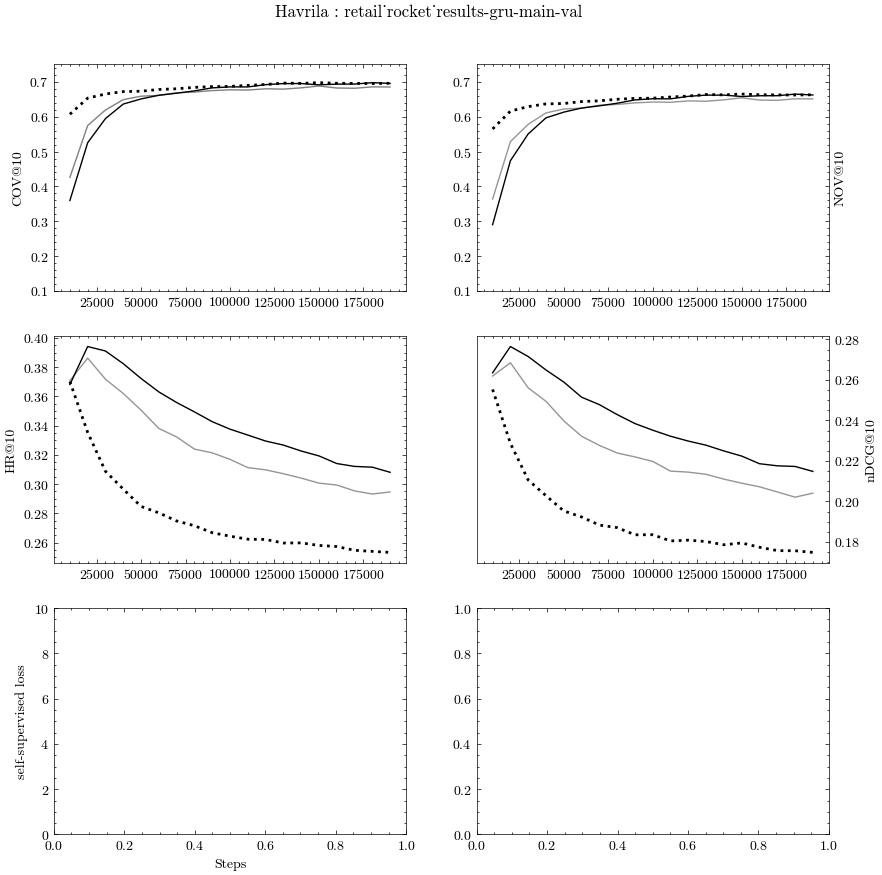

In [33]:
import pandas as pd
from matplotlib import pyplot as plt

def plot_helper(ax, df0, df1, df6, PLOT, col1, col2, window=1):
    yname = ylab_helper(PLOT)
    ax.set_ylabel(yname, color=col1)
    PLOT1 = PLOT
    if PLOT != 'smorl':
        if PLOT == 'plain':
            PLOT1 = 'loss'
        ax.plot(df0['steps'], df0[PLOT1].rolling(window).mean(), color=col1, linestyle=":", linewidth=2)
    ax.plot(df1['steps'], df1[PLOT].rolling(window).mean(), color=col2(0.5), linewidth=1)
    ax.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color=col1, linewidth=1)
    

def plot_metrics(basepath, dataset, model, replica, testorval, window=1):
    filepath1 = f"{basepath}Havrila_both/{dataset}/{model}"
    filepath2 = f"{basepath}Havrila_unfix/{dataset}/{model}"
    dataline = "metrics"
    df0 = pd.read_pickle(f"{filepath1}/base_{dataline}")
    df1 = pd.read_pickle(f"{filepath2}/rl_1_100_{replica}_{dataline}")
    df6 = pd.read_pickle(f"{filepath2}/rl_1_111_{replica}_{dataline}")
    
    #~~~~~~ Plot cov + nov values ~~~~~~
    fig, axs = plt.subplots(3, 2, figsize=(10, 10))
    fig.suptitle(f'Havrila : {dataset}-{model}-{replica}-{testorval}', fontsize=12, y=0.94)
     
    PLOT = f"cov_{testorval}_10"
    ax1 = axs[0, 0]
    #ax1.set_title("COV 10 / NOV 10", fontsize=10, pad=10)
    ax1.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax1.set_ylabel(yname, color="black")
    ax1.plot(df0['steps'], df0[PLOT].rolling(window).mean(), color='black', linestyle=":", linewidth=2, label="Vanilla")
    ax1.plot(df1['steps'], df1[PLOT].rolling(window).mean(), color='0.5', linewidth=1, label="SMORL4RS[1.0.0] - SQN")
    ax1.plot(df6['steps'], df6[PLOT].rolling(window).mean(), color="black", linewidth=1, label="SMORL4RS[1.1.1]")
    
    PLOT = f"nov_{testorval}_10"
    ax2 = axs[0, 1]
    ax2.set_ylim(0.1, 0.75)
    yname = ylab_helper(PLOT)
    ax2.set_ylabel(yname, color='black')
    ax2.yaxis.set_label_position("right")
    plot_helper(ax2, df0, df1, df6, PLOT, 'black', grey)
       
    #~~~~~~ Plot hr + ndcg ~~~~~~   
    PLOT = f"hr_{testorval}_10"
    ax5 = axs[1, 0]
    #ax5.set_title("HR 10 / NDCG 10", fontsize=10, pad=10)
    plot_helper(ax5, df0, df1, df6, PLOT, 'black', grey)
        
    PLOT = f"ndcg_{testorval}_10"
    ax6 = axs[1, 1]
    ax6.yaxis.set_label_position("right")
    ax6.yaxis.tick_right() 
    plot_helper(ax6, df0, df1, df6, PLOT, 'black', grey) 
          
    # ~~~~~~ Plot losses ~~~~~~
    dataline = "loss"
    dfl0 = pd.read_pickle(f"{filepath1}/base_{dataline}")
    dfl1 = pd.read_pickle(f"{filepath2}/rl_1_100_{replica}_{dataline}")
    dfl6 = pd.read_pickle(f"{filepath2}/rl_1_111_{replica}_{dataline}") 
              
    PLOT = "plain"
    ax9 = axs[2, 0]
    #ax9.set_title("Loss components", fontsize=10, pad=10)
    ax9.set_ylim(0, 10)
    yname = ylab_helper(PLOT)
    ax9.set_ylabel(yname, color='black')
    ax9.set_xlabel("Steps", color='black')
    plot_helper(ax9, dfl0, dfl1, dfl6, PLOT, 'black', grey, window=5)
    #ax9.plot(dfl1['steps'], dfl1[PLOT].rolling(5).mean(), color='0.5', linewidth=1)
    #ax9.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='black', linewidth=1)

    PLOT = "smorl"
    ax10 = axs[2,1]
    yname = ylab_helper(PLOT)
    ax10.set_ylabel(yname, color='black')
    ax10.set_xlabel("Steps", color='black')
    ax10.yaxis.set_label_position("right")
    ax10.yaxis.tick_right()
    ax10.set_ylim(0, 10)
    ax10.plot(dfl1['steps'], dfl1[PLOT].rolling(5).mean(), color='0.5', linewidth=1)
    ax10.plot(dfl6['steps'], dfl6[PLOT].rolling(5).mean(), color='black', linewidth=1)
    
    for i, ax in enumerate(axs.flat):
        ax.yaxis.grid(True, color='lightgray', linewidth=0.5)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=8)
        for child in ax.figure.axes:
            child.tick_params(axis='y', labelsize=8)
            child.tick_params(axis='x', labelsize=8)
    
    fig.legend(
        loc='lower center',
        ncol=2,                  # number of columns in legend
        bbox_to_anchor=(0.5, -0.02),  # center below figure
        fontsize='medium'
    )
    
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    fig.savefig(f"{basepath}Havrila_both/Simple-{dataset}-{model}-{replica}-{testorval}.png", dpi=300, bbox_inches='tight')
    plt.close(fig)

models = ["gru", "caser", "sasrec"]
basepath = "/home/marek/Kinit/my_smorl/Plots/"
datasets = ['retail_rocket_results']
for dataset in datasets:
    for model in models: 
        for replica in ['main', 'target']:
            for variant in ['val']:
                plot_metrics(basepath, dataset, model, replica, variant)
            